##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise 

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

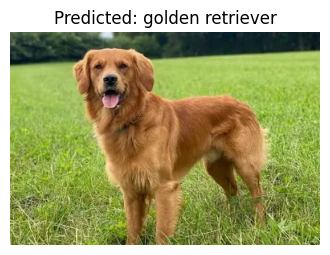

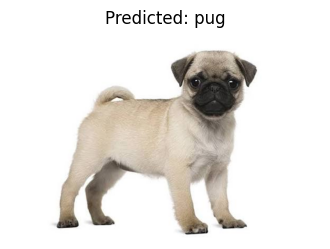

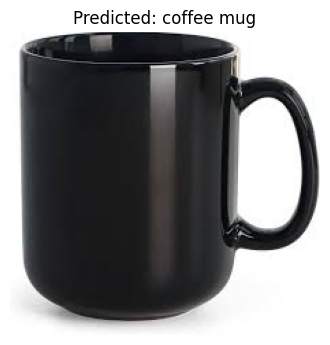

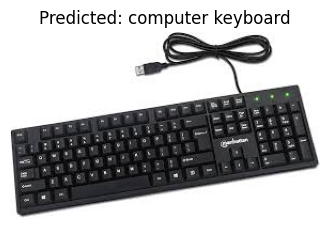

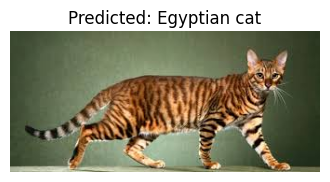

In [17]:
# Import Libraries
import numpy as np
from PIL import Image
import tensorflow as tf
import keras_hub

# Load ImageNet class names
with open("/Users/sarahalashgar/Downloads/imagenet_classes.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]


# Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)


# Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)
model = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet"
)


# Load the images
image_paths = [
"/Users/sarahalashgar/Downloads/gr.webp",
"/Users/sarahalashgar/Downloads/pug.jpeg",
"/Users/sarahalashgar/Downloads/coffe.jpeg",
"/Users/sarahalashgar/Downloads/keyboard.jpeg",
"/Users/sarahalashgar/Downloads/tiger cat.jpeg"
]

images = []

for path in image_paths:
    img = Image.open(path).convert("RGB")
    img = np.array(img, dtype=np.uint8)
    images.append(img)


# Predict classes
processed = []

for img in images:
    img_tf = tf.convert_to_tensor(img, dtype=tf.uint8)
    img_tf = tf.expand_dims(img_tf, axis=0)
    img_tf = preprocessor(img_tf)
    processed.append(img_tf)

x = tf.concat(processed, axis=0)

predictions = model(x)
predicted_classes = tf.argmax(predictions, axis=1)

# Show images with predicted labels
for i, idx in enumerate(predicted_classes):
    plt.figure(figsize=(4,4))
    plt.imshow(images[i])
    plt.title(f"Predicted: {class_names[int(idx)]}")
    plt.axis("off")
    plt.show()

### Record Your Results

Fill the table below based on your results:

| Image File   | Predicted Label | True Label (What you searched) | Correct? (Yes/No) |
| ------------ | --------------- | ------------------------------ | ----------------- |
|     gr.webp         | golden reteiver          |       golden retreiver                         | Yes           |
|      pug.jpeg        | pug          |              pug                  | Yes            |
|    coffee.jpeg          | coffee mug        |    coffee mug                          | Yes           |
|      keyboard.jpeg        | computer keyboard        |   computer keyboard                    | Yes            |
|    tiger cat.jpeg          | egyptian cat         |           tiger cat                     | No           |
